####NEXT WORD PREDICTION - TRANSFORMER

## Install & Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import random
import re
from collections import Counter
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

 Using device: cuda
   GPU: Tesla T4


## Training Corpus
We use a small built-in corpus. You can replace `corpus_text` with any large text.

In [ ]:
corpus_text = """
The transformer model revolutionized natural language processing using self-attention to weigh word importance.
Unlike recurrent networks, it processes tokens in parallel with encoder-decoder architecture.
Positional encoding provides word order information.
Deep learning models learn representations automatically, with language models predicting next words from context.
Attention focuses on relevant input parts, while neural networks consist of layered interconnected neurons.
Training minimizes loss using gradient descent and backpropagation.
Softmax converts logits to probabilities, and embeddings map words to dense vectors.
Large language models are pretrained on massive datasets and fine-tuned for specific tasks.
Multi-head attention captures diverse relationships, supported by residual connections and layer normalization.
Feedforward layers apply linear transformations, while dropout prevents overfitting.
Cross-entropy loss evaluates predictions, and optimizers like Adam adjust learning rates.
Sampling methods (top-k, nucleus, temperature) control text generation.
Beam search improves output quality, and tokenization splits text into subword units.
"""
print(f'Corpus loaded: {len(corpus_text)} characters')

📄 Corpus loaded: 1173 characters


## Tokenizer & Vocabulary

In [ ]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    tokens = text.split()
    return tokens

class Vocabulary:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<UNK>': 1, '<BOS>': 2, '<EOS>': 3}
        self.idx2word = {0: '<PAD>', 1: '<UNK>', 2: '<BOS>', 3: '<EOS>'}

    def build(self, tokens):
        freq = Counter(tokens)
        for word, count in freq.items():
            if count >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        print(f'Vocabulary size: {len(self.word2idx)} tokens')

    def encode(self, tokens):
        return [self.word2idx.get(t, 1) for t in tokens]

    def decode(self, indices):
        return [self.idx2word.get(i, '<UNK>') for i in indices]

    def __len__(self):
        return len(self.word2idx)

# Build vocabulary
all_tokens = tokenize(corpus_text)
vocab = Vocabulary(min_freq=1)
vocab.build(all_tokens)

# Encode the full corpus
encoded = vocab.encode(all_tokens)
print(f'Total tokens: {len(encoded)}')
print(f'Sample tokens: {all_tokens[:10]}')
print(f'Sample encoded: {encoded[:10]}')

Vocabulary size: 130 tokens
Total tokens: 149
Sample tokens: ['the', 'transformer', 'model', 'revolutionized', 'natural', 'language', 'processing', 'using', 'self', 'attention']
Sample encoded: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


## Dataset: Sliding Window Sequences

In [ ]:
from torch.utils.data import Dataset, DataLoader

class NextWordDataset(Dataset):
    def __init__(self, encoded_tokens, seq_len):
        self.data = encoded_tokens
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx : idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.data[idx + 1 : idx + self.seq_len + 1], dtype=torch.long)
        return x, y
SEQ_LEN    = 20
BATCH_SIZE = 32
dataset    = NextWordDataset(encoded, SEQ_LEN)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f'Dataset size: {len(dataset)} samples')
print(f' Batches per epoch: {len(dataloader)}')
xb, yb = next(iter(dataloader))
print(f'Input shape:  {xb.shape}  → (batch, seq_len)')
print(f'Target shape: {yb.shape}  → (batch, seq_len)')

Dataset size: 129 samples
 Batches per epoch: 5
Input shape:  torch.Size([32, 20])  → (batch, seq_len)
Target shape: torch.Size([32, 20])  → (batch, seq_len)


## Transformer Architecture

We build a **GPT-style causal Transformer** from scratch:

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model%num_heads == 0
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def split_heads(self, x):
        B, T, D = x.shape
        x = x.view(B, T, self.num_heads, self.d_k)
        return x.transpose(1, 2)
    def forward(self, x):
        B, T, _ = x.shape
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        attn   = self.dropout(F.softmax(scores, dim=-1))
        out    = torch.matmul(attn, V)
        out    = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(out)
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ff    = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x
class TransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff,
                 max_len=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm      = nn.LayerNorm(d_model)
        self.head      = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.embedding.weight
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)
    def forward(self, x):
        x = self.pos_enc(self.embedding(x))
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x)
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
VOCAB_SIZE  = len(vocab)
D_MODEL     = 128
NUM_HEADS   = 4
NUM_LAYERS  = 3
D_FF        = 512
DROPOUT     = 0.1
model = TransformerLM(
    vocab_size  = VOCAB_SIZE,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    d_ff        = D_FF,
    max_len     = SEQ_LEN + 10,
    dropout     = DROPOUT
).to(device)

print(f'Model Architecture:')
print(model)
print(f'\nTotal trainable parameters: {model.count_parameters():,}')

Model Architecture:
TransformerLM(
  (embedding): Embedding(130, 128, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=512, out_features=128, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    



## Training Loop

In [ ]:
EPOCHS    = 80
LR        = 3e-3
CLIP_GRAD = 1.0
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(ignore_index=0)
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)                              # (B, T, vocab)
        loss   = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)
print('Starting training...\n')
loss_history = []
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(model, dataloader, optimizer, criterion)
    scheduler.step()
    loss_history.append(loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  Loss: {loss:.4f}  '
              f'Perplexity: {math.exp(loss):.2f}  '
              f'LR: {scheduler.get_last_lr()[0]:.6f}')

print('\n Training complete!')

Starting training...

Epoch [  1/80]  Loss: 4.5618  Perplexity: 95.76  LR: 0.002999
Epoch [ 10/80]  Loss: 3.8794  Perplexity: 48.39  LR: 0.002886
Epoch [ 20/80]  Loss: 3.1872  Perplexity: 24.22  LR: 0.002561
Epoch [ 30/80]  Loss: 2.6595  Perplexity: 14.29  LR: 0.002074
Epoch [ 40/80]  Loss: 2.3746  Perplexity: 10.75  LR: 0.001500
Epoch [ 50/80]  Loss: 1.9496  Perplexity: 7.03  LR: 0.000926
Epoch [ 60/80]  Loss: 1.6908  Perplexity: 5.42  LR: 0.000439
Epoch [ 70/80]  Loss: 1.6603  Perplexity: 5.26  LR: 0.000114
Epoch [ 80/80]  Loss: 1.5489  Perplexity: 4.71  LR: 0.000000

 Training complete!


## Plot Training Loss

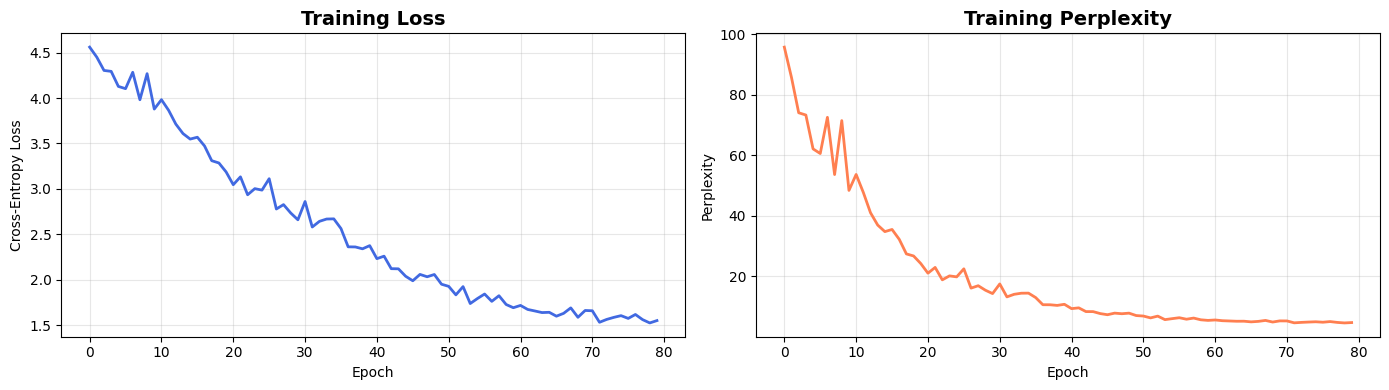

Final Loss: 1.5489 | Final Perplexity: 4.71


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(loss_history, color='royalblue', linewidth=2)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

perplexity = [math.exp(l) for l in loss_history]
axes[1].plot(perplexity, color='coral', linewidth=2)
axes[1].set_title('Training Perplexity', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final Loss: {loss_history[-1]:.4f} | Final Perplexity: {perplexity[-1]:.2f}')

# Next Word Prediction Function

In [ ]:
@torch.no_grad()
def predict_next_words(model, vocab, text, top_k=5, temperature=1.0):
    """
    Predict the top-k most likely next words for a given input text.

    Args:
        model       : Trained TransformerLM
        vocab       : Vocabulary object
        text        : Input string (context)
        top_k       : Number of top predictions to return
        temperature : Softmax temperature (lower = sharper, higher = more diverse)

    Returns:
        List of (word, probability) tuples
    """
    model.eval()
    tokens  = tokenize(text)
    encoded = vocab.encode(tokens)
    if len(encoded) > SEQ_LEN:
        encoded = encoded[-SEQ_LEN:]
    else:
        encoded = [0] * (SEQ_LEN - len(encoded)) + encoded

    x = torch.tensor([encoded], dtype=torch.long).to(device)

    logits = model(x)
    last   = logits[0, -1, :]
    probs = F.softmax(last / temperature, dim=-1)
    topk_probs, topk_idx = torch.topk(probs, top_k)
    results = []
    for prob, idx in zip(topk_probs.cpu().numpy(), topk_idx.cpu().numpy()):
        word = vocab.idx2word.get(idx, '<UNK>')
        results.append((word, float(prob)))
    return results
test_inputs = [
    "the transformer model",
    "attention mechanism allows",
    "neural networks consist",
    "training involves minimizing",
    "language models are",
]

print(' Next Word Predictions\n' + '='*55)
for text in test_inputs:
    preds = predict_next_words(model, vocab, text, top_k=5)
    print(f'\n Input: "{text}"')
    print(f'   → Top-5 next words:')
    for rank, (word, prob) in enumerate(preds, 1):
        bar = ' ' * int(prob * 40)
        print(f'   {rank}. {word:<20} {prob:.4f}  {bar}')

 Next Word Predictions

 Input: "the transformer model"
   → Top-5 next words:
   1. improves             0.2358           
   2. output               0.2233          
   3. search               0.1276       
   4. multi                0.0886     
   5. tasks                0.0876     

 Input: "attention mechanism allows"
   → Top-5 next words:
   1. pretrained           0.3189              
   2. context              0.1069      
   3. top                  0.0919     
   4. methods              0.0895     
   5. connections          0.0714    

 Input: "neural networks consist"
   → Top-5 next words:
   1. using                0.5688                        
   2. loss                 0.1530        
   3. minimizes            0.0854     
   4. gradient             0.0525    
   5. training             0.0312   

 Input: "training involves minimizing"
   → Top-5 next words:
   1. context              0.2494           
   2. pretrained           0.1416       
   3. interconnected       

## Text Generation (Auto-Complete)

In [ ]:
@torch.no_grad()
def generate_text(model, vocab, seed_text, num_words=20, temperature=0.8,
                  top_k=10, strategy='top_k'):
    """
    Auto-complete text using the trained Transformer.

    Strategies:
        'greedy'  — always pick the highest-probability word
        'top_k'   — sample from top-k candidates
        'nucleus' — sample from smallest set with cumulative prob >= p
    """
    model.eval()
    tokens  = tokenize(seed_text)
    encoded = vocab.encode(tokens)

    generated = list(encoded)

    for _ in range(num_words):
        context = generated[-SEQ_LEN:]
        padded  = [0] * (SEQ_LEN - len(context)) + context
        x       = torch.tensor([padded], dtype=torch.long).to(device)

        logits  = model(x)[0, -1, :]
        probs   = F.softmax(logits / temperature, dim=-1)

        if strategy == 'greedy':
            next_id = torch.argmax(probs).item()

        elif strategy == 'top_k':
            topk_p, topk_i = torch.topk(probs, top_k)
            topk_p = topk_p / topk_p.sum()  # renormalize
            next_id = topk_i[torch.multinomial(topk_p, 1)].item()

        elif strategy == 'nucleus':   # top-p = 0.9
            sorted_p, sorted_i = torch.sort(probs, descending=True)
            cum_p = torch.cumsum(sorted_p, dim=0)
            mask  = cum_p - sorted_p < 0.9
            filtered = sorted_p * mask
            filtered = filtered / filtered.sum()
            next_id  = sorted_i[torch.multinomial(filtered, 1)].item()

        generated.append(next_id)

    words = vocab.decode(generated)
    return ' '.join(words)


seed = "the transformer model has"
print(f'🌱 Seed: "{seed}"\n')

for strategy in ['greedy', 'top_k', 'nucleus']:
    result = generate_text(model, vocab, seed, num_words=15, strategy=strategy)
    print(f'[{strategy.upper():7s}]: {result}')

🌱 Seed: "the transformer model has"

[GREEDY ]: the transformer model <UNK> quality and tokenization tokenization tokenization tokenization tokenization tokenization tokenization residual and dropout consist consist consist
[TOP_K  ]: the transformer model <UNK> quality and tokenization and tokenization tokenization tokenization tokenization tokenization residual and training automatically networks in
[NUCLEUS]: the transformer model <UNK> and splits quality tokenization splits splits into subword relationships supported relationships relationships residual residual supported


## Interactive Prediction (Custom Input)

In [ ]:

user_input  = "deep learning models learn"
top_k       = 5
temperature = 0.8
print(f' Input: "{user_input}"')
print(f' Temperature: {temperature}\n')
predictions = predict_next_words(model, vocab, user_input,
                                  top_k=top_k, temperature=temperature)
print(f'{"Rank":<5} {"Word":<25} {"Probability":<14} {"Bar"}')
print('-' * 65)
for i, (word, prob) in enumerate(predictions, 1):
    bar = '' * int(prob * 50)
    print(f'{i:<5} {word:<25} {prob:<14.4f} {bar}')

print(f'\n Best prediction: "{predictions[0][0]}"  ({predictions[0][1]*100:.1f}%)')
print(f' Completed sentence: "{user_input} {predictions[0][0]}"')

 Input: "deep learning models learn"
 Temperature: 0.8

Rank  Word                      Probability    Bar
-----------------------------------------------------------------
1     with                      0.3942         
2     automatically             0.3112         
3     representations           0.0633         
4     language                  0.0573         
5     using                     0.0368         

 Best prediction: "with"  (39.4%)
 Completed sentence: "deep learning models learn with"


## Save & Load Model

In [ ]:
import pickle
torch.save(model.state_dict(), 'transformer_lm.pth')

with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

print(' Model saved to transformer_lm.pth')
print(' Vocabulary saved to vocab.pkl')
with open('vocab.pkl', 'rb') as f:
    loaded_vocab = pickle.load(f)

loaded_model = TransformerLM(
    vocab_size  = len(loaded_vocab),
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_layers  = NUM_LAYERS,
    d_ff        = D_FF,
    max_len     = SEQ_LEN + 10,
    dropout     = 0.0
).to(device)
loaded_model.load_state_dict(torch.load('transformer_lm.pth', map_location=device))
loaded_model.eval()

print('\n Model loaded successfully!')
preds = predict_next_words(loaded_model, loaded_vocab, 'the attention mechanism', top_k=3)
print(f'\n Verification prediction for "the attention mechanism":')
for word, prob in preds:
    print(f'   → {word:20s}  {prob:.4f}')

 Model saved to transformer_lm.pth
 Vocabulary saved to vocab.pkl

 Model loaded successfully!

 Verification prediction for "the attention mechanism":
   → and                   0.2320
   → splits                0.1058
   → supported             0.1019


## Summary & Model Config

In [ ]:

print('   NEXT WORD PREDICTION — TRANSFORMER SUMMARY')
print(f'  Architecture     : GPT-style Causal Transformer')
print(f'  Embedding Dim    : {D_MODEL}')
print(f'  Attention Heads  : {NUM_HEADS}')
print(f'  Transformer Layers: {NUM_LAYERS}')
print(f'  FFN Hidden Dim   : {D_FF}')
print(f'  Context Window   : {SEQ_LEN} tokens')
print(f'  Vocabulary Size  : {len(vocab):,} tokens')
print(f'  Total Parameters : {model.count_parameters():,}')
print(f'  Training Epochs  : {EPOCHS}')
print(f'  Final Loss       : {loss_history[-1]:.4f}')
print(f'  Final Perplexity : {math.exp(loss_history[-1]):.2f}')
print()

   NEXT WORD PREDICTION — TRANSFORMER SUMMARY
  Architecture     : GPT-style Causal Transformer
  Embedding Dim    : 128
  Attention Heads  : 4
  Transformer Layers: 3
  FFN Hidden Dim   : 512
  Context Window   : 20 tokens
  Vocabulary Size  : 130 tokens
  Total Parameters : 611,712
  Training Epochs  : 80
  Final Loss       : 1.5489
  Final Perplexity : 4.71

